In [3]:
import torch
import clip
import requests
from io import BytesIO
from PIL import Image
import numpy as np, matplotlib.pyplot as plt, zipfile, os
from tqdm import tqdm

In [6]:
img_folder = 'photos/'
if not os.path.exists(img_folder) or len(os.listdir(img_folder)) == 0:
    os.makedirs(img_folder, exist_ok=True)

    photo_filename = 'unspalsh-25k-photos.zip'
    if not os.path.exists(photo_filename):
        url = 'http://sbert.net/datasets/unsplash-25k-photos.zip'
        print(f"Downloading {photo_filename} from {url}...")
        response = requests.get(url)
        with open(photo_filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded {photo_filename} successfully.")
    else:
        print(f"{photo_filename} already exists. Skipping download.")
    with zipfile.ZipFile(photo_filename, 'r') as zip_ref:
        for member in tqdm(zip_ref.infolist(), desc="Extracting photos"):
            zip_ref.extract(member, img_folder)

In [8]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
model, preprocess = clip.load("ViT-B/32", device=device)
image_path = [os.path.join(img_folder, f) for f in os.listdir(img_folder) if f.endswith('.jpg')]
image_feature = []
for path in tqdm(image_path, desc='Computing features'):
    image = preprocess(Image.open(path)).unsqueeze(0).to(device)
    with torch.no_grad():
        feature = model.encode_image(image)
    image_feature.append(feature.cpu().numpy())
image_feature = np.concatenate(image_feature, axis=0)
print(f"Computed features for {len(image_feature)} images.")

Using device: mps


Computing features: 100%|██████████| 24996/24996 [09:19<00:00, 44.68it/s]

Computed features for 24996 images.


In [14]:
def search_by_image(query_path, top_k=5):
    image = preprocess(Image.open(query_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        query_feature = model.encode_image(image).cpu().numpy()
    similarities = np.dot(image_feature, query_feature.T).squeeze()
    top_indices = np.argsort(similarities)[::-1][:top_k]
    return [image_path[i] for i in top_indices], similarities[top_indices]

Similarity: 26.5781, Image: photos/FAcSe7SjDUU.jpg


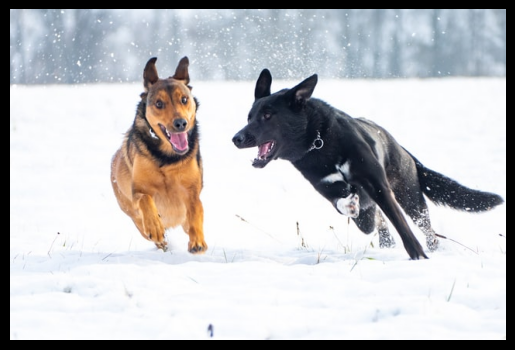

Similarity: 25.5312, Image: photos/JAjrbewMbFQ.jpg


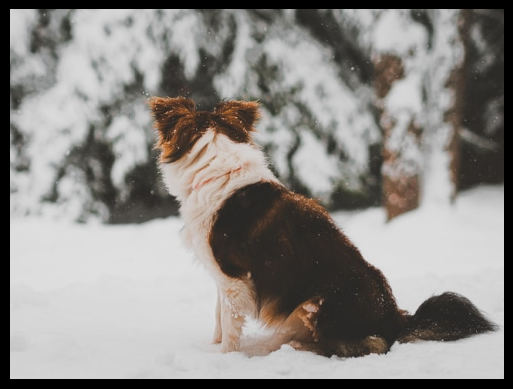

Similarity: 25.4062, Image: photos/7I-1Ba5Psxs.jpg


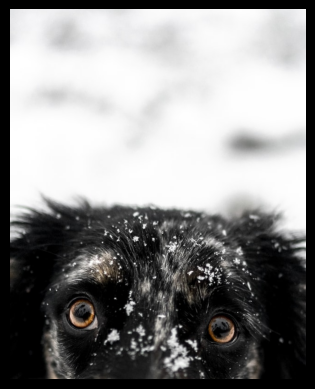

Similarity: 24.7812, Image: photos/FJu_dhnTqlE.jpg


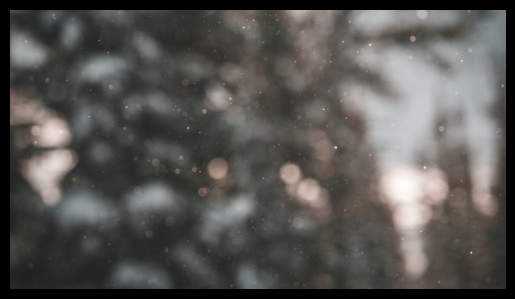

Similarity: 24.5469, Image: photos/u49N64PLEs0.jpg


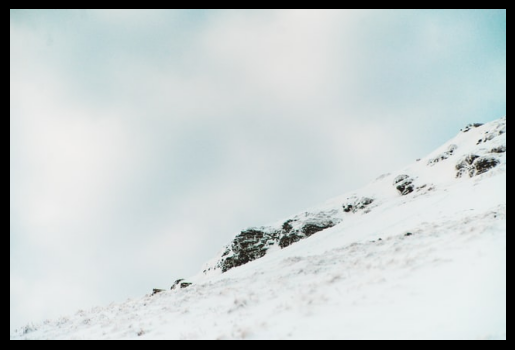

In [11]:
def search_by_text(query, top_k=5):
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_feature = model.encode_text(text).cpu().numpy()
    similarities = np.dot(image_feature, text_feature.T).squeeze()
    top_indices = np.argsort(similarities)[::-1][:top_k]
    return [image_path[i] for i in top_indices], similarities[top_indices]
similar_images, similarity_score = search_by_text("two dogs playing in the snow", top_k=5)
for path, score in zip(similar_images, similarity_score):
    print(f"Similarity: {score:.4f}, Image: {path}")
    plt.imshow(Image.open(path))
    plt.axis('off')
    plt.show()

Similarity: 30.9375, Image: photos/gtp_e6B5ZtM.jpg


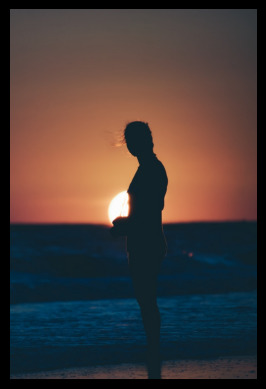

Similarity: 30.6406, Image: photos/3DsxYjhozPQ.jpg


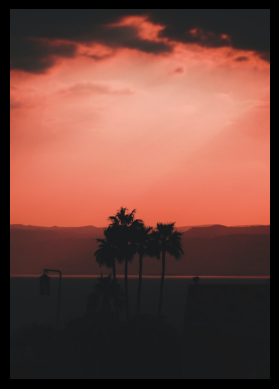

Similarity: 30.5938, Image: photos/E7wX4dyeNLI.jpg


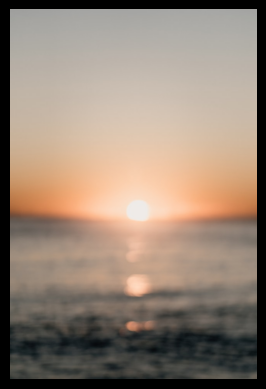

Similarity: 30.5781, Image: photos/CgksNg0iiI8.jpg


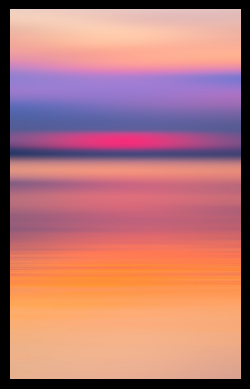

Similarity: 30.5625, Image: photos/iRlPnaQ3BeY.jpg


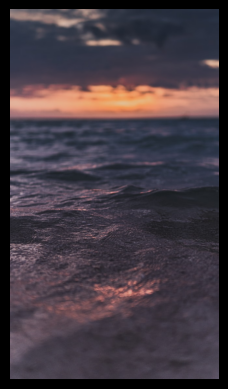

In [12]:
similar_images, similarity_score = search_by_text("A sunset on the beach", top_k=5)
for path, score in zip(similar_images, similarity_score):
    print(f"Similarity: {score:.4f}, Image: {path}")
    plt.imshow(Image.open(path))
    plt.axis('off')
    plt.show()

Similarity: 37.9062, Image: photos/upypO_FbRJ4.jpg


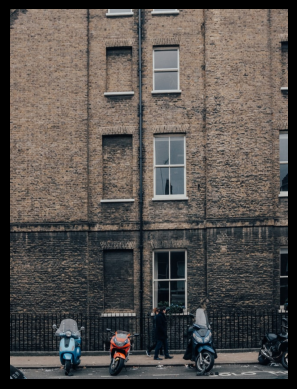

Similarity: 36.7188, Image: photos/waFfUmq0tWQ.jpg


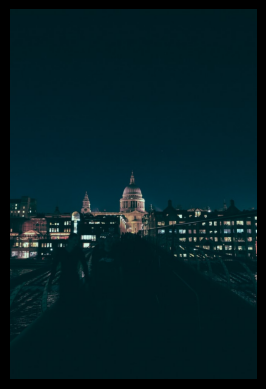

Similarity: 36.5938, Image: photos/ZtNhsHfjorY.jpg


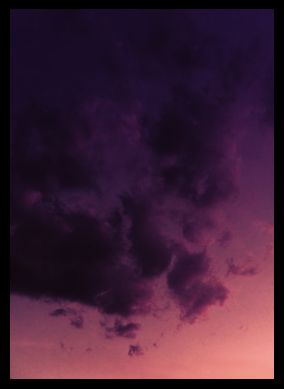

Similarity: 36.4688, Image: photos/tXVdXChOeZI.jpg


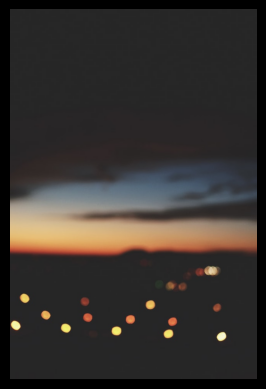

Similarity: 36.1875, Image: photos/0ufkmj46xvU.jpg


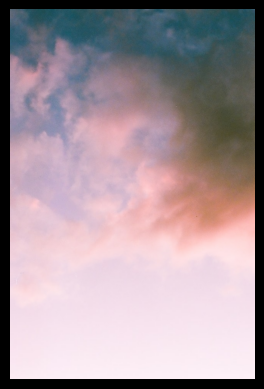

In [13]:
similar_images, similarity_score = search_by_text("London", top_k=5)
for path, score in zip(similar_images, similarity_score):
    print(f"Similarity: {score:.4f}, Image: {path}")
    plt.imshow(Image.open(path))
    plt.axis('off')
    plt.show()

Similarity: 121.2500, Image: photos/FAcSe7SjDUU.jpg


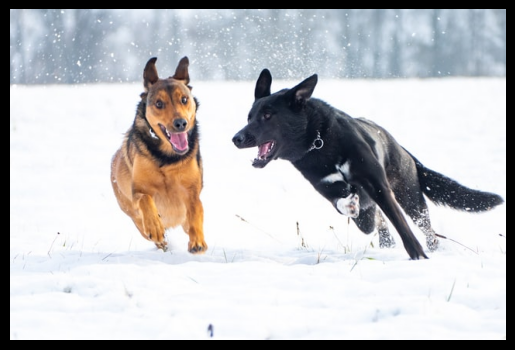

Similarity: 107.3125, Image: photos/5sVAy79gODU.jpg


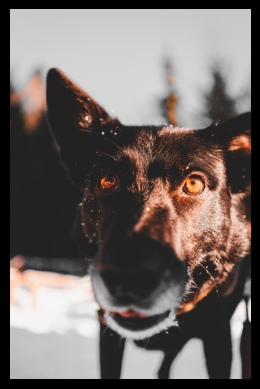

Similarity: 106.8125, Image: photos/wEedibptB34.jpg


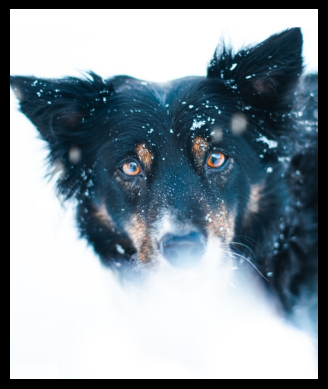

Similarity: 106.6875, Image: photos/rdxTb9pcS2Y.jpg


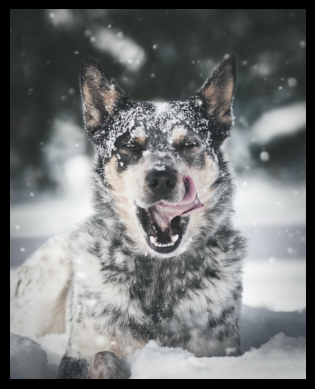

Similarity: 106.3750, Image: photos/U8hfWW6uRvk.jpg


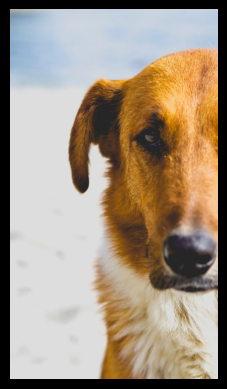

In [17]:
similar_images, similarity_scores = search_by_image('photos/FAcSe7SjDUU.jpg', top_k=5)
for path, score in zip(similar_images, similarity_scores):
    print(f"Similarity: {score:.4f}, Image: {path}")
    plt.imshow(Image.open(path))
    plt.axis('off')
    plt.show()